### Alternative Leaf Function (Logistic Regression)

/opt/homebrew/anaconda3/envs/text_analytics/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


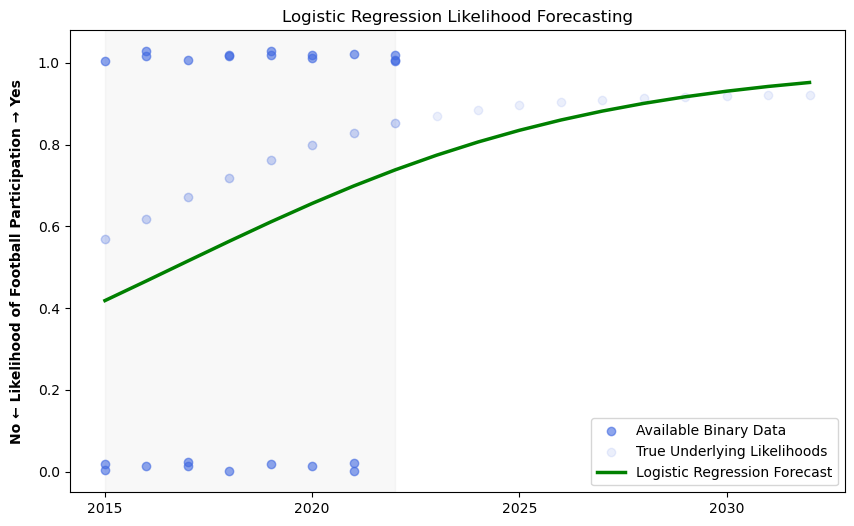

In [4]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# https://scikit-learn.org/stable/auto_examples/ensemble/plot_feature_transformation.html

np.random.seed(0)
def sigmoid(x):
    return 1/(1 + np.exp(-x))
def true_fn(x):
    return sigmoid(0.28 * (x - 2014)) - 0.025 * np.log(x - 2014)

training_years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
forecast_years = [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032]

train_x = np.repeat(training_years, repeats = 3).reshape(-1, 1)
train_probs = true_fn(train_x)
train_binary = np.random.binomial(n = 1, p = train_probs)
forecast_x = np.repeat(forecast_years, 1).reshape(-1, 1)
forecast_probs = true_fn(forecast_x)
full_x = np.concat([train_x, forecast_x])
true_probs = np.concat([train_probs, forecast_probs])

LR = LogisticRegression()
LR.fit(train_x, train_binary)
predicted_probs = LR.predict_proba(full_x)[:, 1]
 
plt.figure(figsize=(10, 6))
plt.title('Logistic Regression Likelihood Forecasting')
plt.axvspan(xmin = 2015, xmax = 2022, color = 'grey', alpha = 0.05)
plt.scatter(train_x, train_binary + np.random.uniform(0, 0.03, size = train_binary.shape), color = 'royalblue', label = 'Available Binary Data', alpha = 0.6)
plt.scatter(full_x, true_probs, color = 'royalblue', label = 'True Underlying Likelihoods', alpha = 0.1)
plt.plot(full_x, predicted_probs, color = 'green', linewidth = 2.5, label = 'Logistic Regression Forecast')
plt.xticks(np.arange(2015, 2031, 5))
plt.ylabel('No ← Likelihood of Football Participation → Yes', fontsize = 10, labelpad = 10, fontweight = "bold")
plt.legend(loc = 'lower right')
plt.show()